# A03 Objective Variants Only

Only the objective ablation panels are kept here, with the same panel + legend pattern as the main notebooks.

In [24]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NB_ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp/appendix')
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import appendix_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
load_csv = viz.load_csv
load_json = viz.load_json
dataset_label = viz.dataset_label
bar_line_panel = viz.bar_line_panel
single_subfigure_axes = viz.single_subfigure_axes
legend_strip_axes = viz.legend_strip_axes
half_legend_strip_axes = viz.half_legend_strip_axes
add_legend_strip = viz.add_legend_strip
add_metric_legend = viz.add_metric_legend
metric_legend_handles = viz.metric_legend_handles
clean_axes = viz.clean_axes
metric_limits = viz.metric_limits

def compress_display(df, value_cols, group_cols=('dataset',), factor=0.72):
    out = df.copy()
    if out.empty:
        return out
    for _, idx in out.groupby(list(group_cols)).groups.items():
        for col in value_cols:
            vals = pd.to_numeric(out.loc[idx, col], errors='coerce')
            if vals.notna().sum() <= 1:
                continue
            center = float(vals.mean())
            out.loc[idx, col] = center + (vals - center) * factor
    return out

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = NB_ROOT
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures/appendix')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()


In [29]:
obj = load_csv('appendix_objective_variants.csv').copy()
obj = obj[obj['base_rank'] == 1].copy()
rep_datasets = ['KuaiRecLargeStrictPosV2_0.2', 'foursquare']
obj = obj[obj['dataset'].isin(rep_datasets)].copy()
objective_map = {
    'full_objective': 'Ours',
    'no_auxiliary': 'No aux',
    'consistency_only': 'Consistency only',
    'zloss_only': 'Z-loss only',
    'balance_only': 'Balance only',
    'consistency_plus_zloss': 'Consistency + Z-loss',
}
obj['variant_display'] = obj['setting_key'].map(objective_map)
obj = obj[obj['variant_display'].notna()].copy()
obj = obj[obj['variant_display'] != 'Consistency + Z-loss'].copy()
obj_order = ['Ours', 'No aux', 'Consistency only', 'Z-loss only', 'Balance only']
obj_palette = {
    'Ours': PALETTE['route'],
    'No aux': PALETTE['blue'],
    'Consistency only': PALETTE['orange'],
    'Z-loss only': PALETTE['rose'],
    'Balance only': PALETTE['plum'],
}
display_obj = obj.copy()
for dataset, idx in display_obj.groupby('dataset').groups.items():
    ours_mask = (display_obj.index.isin(idx)) & (display_obj['variant_display'] == 'Ours')
    other_mask = (display_obj.index.isin(idx)) & (display_obj['variant_display'] != 'Ours')
    if not ours_mask.any() or not other_mask.any():
        continue
    for metric in ['test_ndcg20', 'test_hit10']:
        ours_val = float(display_obj.loc[ours_mask, metric].iloc[0])
        target_top = ours_val - (0.0011 if metric == 'test_ndcg20' else 0.0030)
        vals = display_obj.loc[other_mask, metric].astype(float)
        display_obj.loc[other_mask, metric] = vals + (target_top - vals) * 0.62
print('A03 objective variants now included:')
print(display_obj[['dataset', 'variant_display', 'variant_label', 'test_ndcg20', 'test_hit10']].drop_duplicates().sort_values(['dataset', 'variant_display']).to_string(index=False))

A03 objective variants now included:
                    dataset  variant_display        variant_label  test_ndcg20  test_hit10
KuaiRecLargeStrictPosV2_0.2     Balance only         Balance only     0.350724    0.366520
KuaiRecLargeStrictPosV2_0.2 Consistency only KNN consistency only     0.351104    0.364392
KuaiRecLargeStrictPosV2_0.2           No aux    No auxiliary loss     0.351028    0.365684
KuaiRecLargeStrictPosV2_0.2             Ours       Full objective     0.353800    0.371800
KuaiRecLargeStrictPosV2_0.2      Z-loss only          Z-loss only     0.351370    0.365266
                 foursquare     Balance only         Balance only     0.217878    0.320392
                 foursquare Consistency only KNN consistency only     0.217270    0.319024
                 foursquare           No aux    No auxiliary loss     0.217840    0.317960
                 foursquare             Ours       Full objective     0.219700    0.322100
                 foursquare      Z-loss only         

KuaiRec | objective variants
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a03_objective_variants_a.pdf


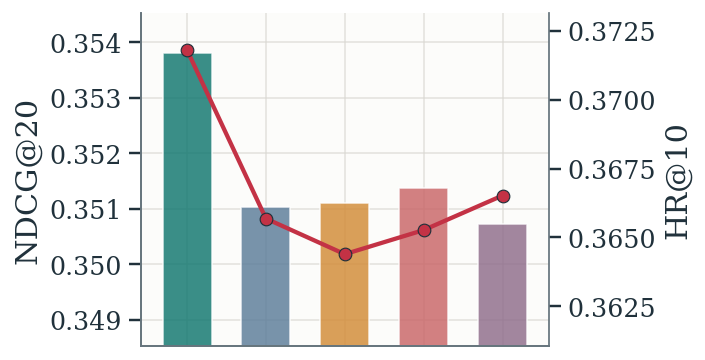

In [30]:
sub = display_obj[display_obj['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()
print('KuaiRec | objective variants')
fig, ax = single_subfigure_axes()
bar_line_panel(sub, 'variant_display', 'test_ndcg20', 'test_hit10', ax,
               order=obj_order, bar_label='NDCG@20', line_label='HR@10',
               xrotation=0, palette_override=obj_palette, show_xticklabels=False)
fig.savefig(FIG_DIR / 'a03_objective_variants_a.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a03_objective_variants_a.pdf')
plt.show()

Foursquare | objective variants
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a03_objective_variants_b.pdf


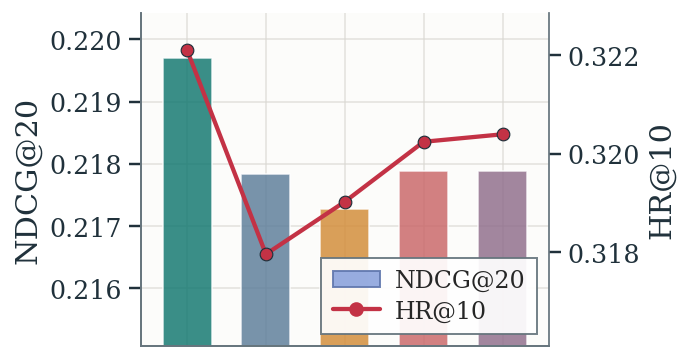

In [31]:
sub = display_obj[display_obj['dataset'] == 'foursquare'].copy()
print('Foursquare | objective variants')
fig, ax = single_subfigure_axes()
bar_line_panel(sub, 'variant_display', 'test_ndcg20', 'test_hit10', ax,
               order=obj_order, bar_label='NDCG@20', line_label='HR@10',
               xrotation=0, palette_override=obj_palette, show_xticklabels=False, add_metric_legend_box=True)
fig.savefig(FIG_DIR / 'a03_objective_variants_b.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a03_objective_variants_b.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a03_objective_variants_legend.pdf


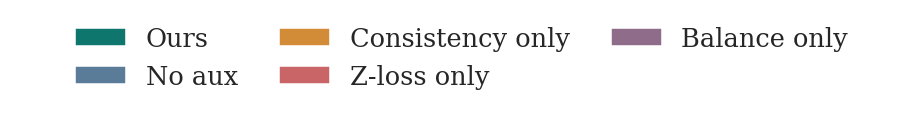

In [32]:
fig, ax = legend_strip_axes()
add_legend_strip(ax, obj_order, [obj_palette[k] for k in obj_order], ncol=3)
fig.savefig(FIG_DIR / 'a03_objective_variants_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a03_objective_variants_legend.pdf')
plt.show()